In [1]:
# 安置在头皮上的电极称为作用电极（active electrode）
# 放置在身体相对零电位点的电极称为参考电极（reference electrode）
# 记录到的脑电信号就是两者的电位差

In [2]:
import mne
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

In [4]:
#
raw = mne.io.read_raw_fif("../data/sample_audvis_raw.fif")
raw.crop(tmax=60).load_data()
raw.pick(['EEG 0{:02}'.format(n) for n in range(41, 60)])

Opening raw data file ../data/sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.
Reading 0 ... 36037  =      0.000 ...    60.000 secs...


<Raw | sample_audvis_raw.fif, 19 x 36038 (60.0 s), ~8.1 MiB, data loaded>

Using matplotlib as 2D backend.


D:\Miniconda\envs\mne_demo_env\lib\site-packages\mne\viz\_mpl_figure.py:2160: UserWarning: Glyph 181 (\N{MICRO SIGN}) missing from font(s) SimHei.
  self.canvas.draw_idle()
D:\Miniconda\envs\mne_demo_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 181 (\N{MICRO SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


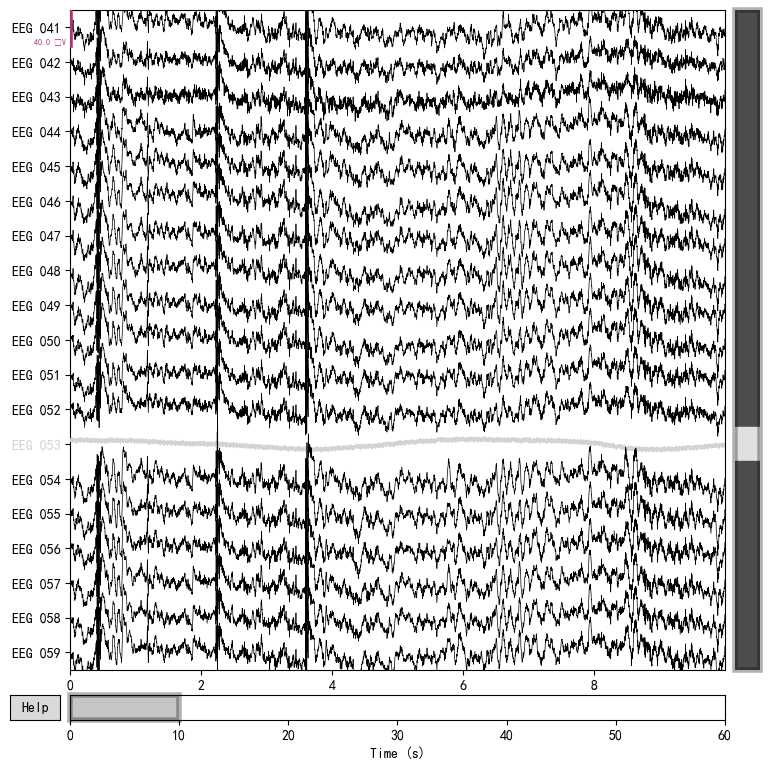

In [5]:
# 原始状态
raw.plot()
plt.show()

D:\Miniconda\envs\mne_demo_env\lib\site-packages\mne\viz\_mpl_figure.py:2160: UserWarning: Glyph 181 (\N{MICRO SIGN}) missing from font(s) SimHei.
  self.canvas.draw_idle()
D:\Miniconda\envs\mne_demo_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 181 (\N{MICRO SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


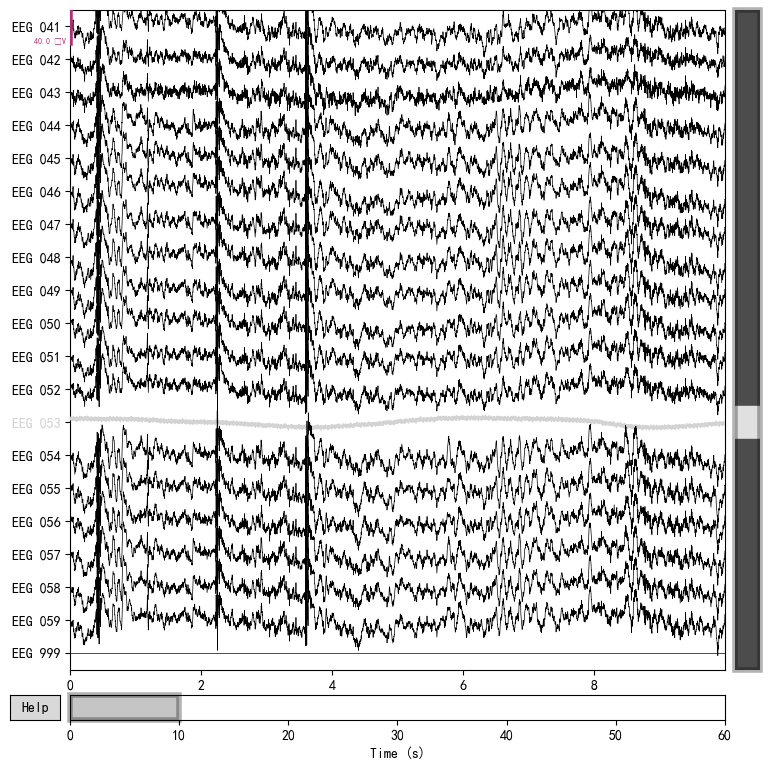

In [6]:
# 添加一个参考通道
raw_new_ref = mne.add_reference_channels(raw, ref_channels=['EEG 999'])
raw_new_ref.plot()
plt.show()

EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.


D:\Miniconda\envs\mne_demo_env\lib\site-packages\mne\viz\_mpl_figure.py:2160: UserWarning: Glyph 181 (\N{MICRO SIGN}) missing from font(s) SimHei.
  self.canvas.draw_idle()
D:\Miniconda\envs\mne_demo_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 181 (\N{MICRO SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


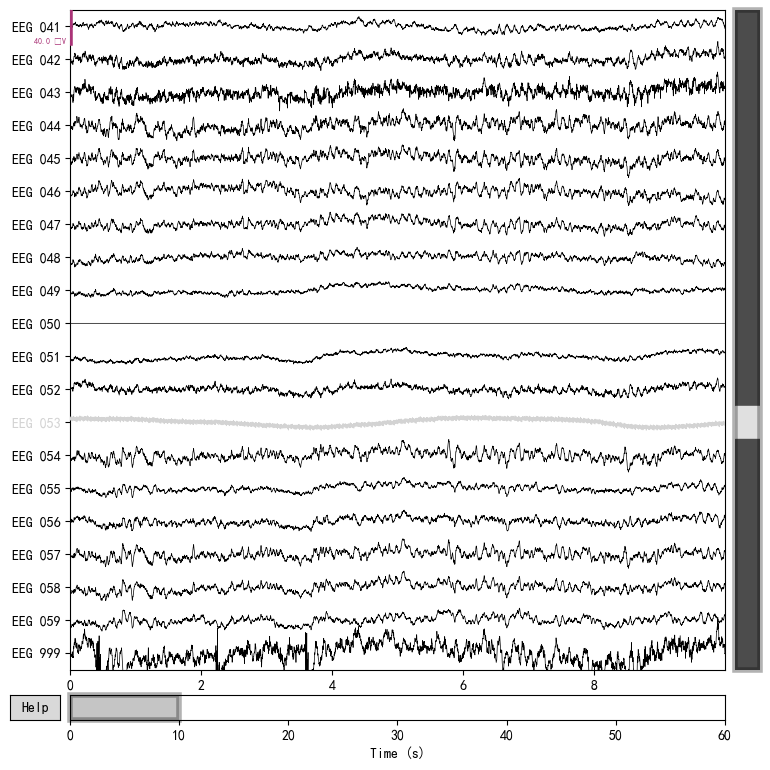

In [8]:
# 设置EEG 050作为参考电极
raw_new_ref.set_eeg_reference(ref_channels=['EEG 050'])
raw_new_ref.plot()
plt.show()

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


D:\Miniconda\envs\mne_demo_env\lib\site-packages\mne\viz\_mpl_figure.py:2160: UserWarning: Glyph 181 (\N{MICRO SIGN}) missing from font(s) SimHei.
  self.canvas.draw_idle()
D:\Miniconda\envs\mne_demo_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 181 (\N{MICRO SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


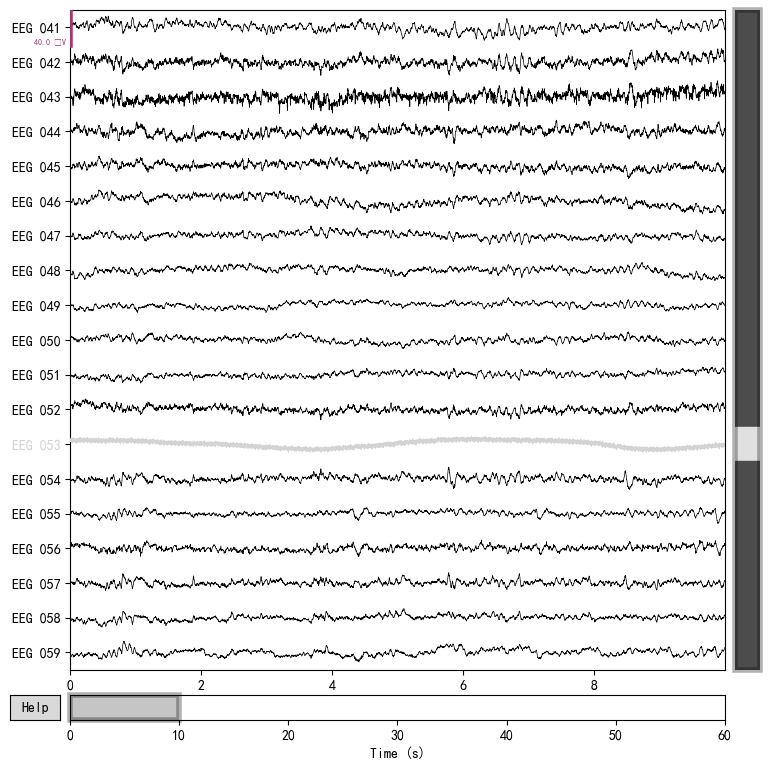

In [12]:
# 将所有通道的平均值作为参考
raw_avg_ref = raw.copy().set_eeg_reference(ref_channels='average')
raw_avg_ref.plot()
plt.show()

In [20]:
#